In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time


In [12]:

"""
Wanted to Preface and say I know there is a lot, I have what canvas asks for but also have Diagonal Domminance,
and other code from class on Tuesday
"""

'\nWanted to Preface and say I know there is a lot, I have what canvas asks for but also have Diagonal Domminance,\nand other code from class on Tuesday\n'

In [2]:
tols = 1e-6
max_iterations = 100


A = np.array([
	[0.582745, 0.48	, 0.10	, 0.  	, 0.  	], 
 [0.48	, 1.044129, 0.46	, 0.10	, 0.  	],
 [0.10	, 0.46	, 1.10431 , 0.44	, 0.10	],
 [0.  	, 0.10	, 0.44	, 0.963889, 0.42	],
 [0.  	, 0.  	, 0.10	, 0.42	, 0.522565]], dtype=float)
b = np.array([1.162745, 2.084129, 2.20431 , 1.923889, 1.042565], dtype=float)

x0 = np.zeros_like(b, dtype=float)


In [3]:
def jacobi(A, b, x0, tol, max_iterations):
    start_time = time.perf_counter()
    n = len(b)

    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x = np.array(x0, dtype=float).copy()

    errors = []

    for k in range(max_iterations):
        x_new = np.zeros_like(x)

        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]

        
        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)

        if err < tol:
            duration = time.perf_counter() - start_time
            return x_new, (k), duration, np.array(errors)

        x = x_new

    return x, max_iterations, time.perf_counter() - start_time, err

In [4]:
def gauss_seidel(A, b, x0, tol, max_iterations):
    start_time = time.perf_counter()

    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x = np.array(x0, dtype=float).copy()

    n = len(b)
    errors = []


    for k in range(max_iterations):
        x_new = x.copy()

        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))        
            s2 = sum(A[i][j] * x[j]     for j in range(i + 1, n))  
            x_new[i] = (b[i] - s1 - s2) / A[i][i]

        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)

        if err < tol:
            duration = time.perf_counter() - start_time
            return x_new, k , duration, np.array(errors)

        x = x_new

    return x, max_iterations, time.perf_counter() - start_time, err

In [5]:
tol = 1e-6  # example tolerance

xJ, itJ, timeJ, errJ = jacobi(A, b, x0, tol, max_iterations)
xG, itG, timeG, errG = gauss_seidel(A, b, x0, tol, max_iterations)

print(f"Tolerance = {tol}")

print("\nJacobi:")
print("Iterations:", itJ)
print("Time:", timeJ)

print("\nGauss-Seidel:")
print("Iterations:", itG)
print("Time:", timeG)

Tolerance = 1e-06

Jacobi:
Iterations: 100
Time: 0.005682511255145073

Gauss-Seidel:
Iterations: 20
Time: 0.0011103395372629166


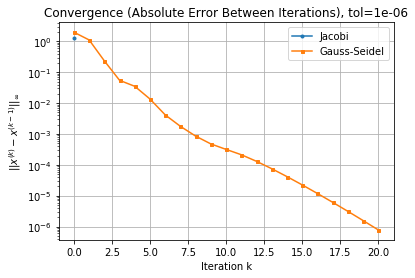

In [6]:
plt.figure()
plt.semilogy(errJ, marker='o', markersize=3, label="Jacobi")
plt.semilogy(errG, marker='s', markersize=3, label="Gauss-Seidel")
plt.xlabel("Iteration k")
plt.ylabel(r"$||x^{(k)} - x^{(k-1)}||_\infty$")
plt.title(f"Convergence (Absolute Error Between Iterations), tol={tol}")
plt.grid(True, which="Major")
plt.legend()
plt.show()

In [7]:
A = np.array([[1, 	1], [1, 1.0001]])
b = np.array([1, 1])

In [8]:
tol = 1e-3  # example tolerance

xJ, itJ, timeJ, errJ = jacobi(A, b, x0, tol, max_iterations)
xG, itG, timeG, errG = gauss_seidel(A, b, x0, tol, max_iterations)

print(f"Tolerance = {tol}")

print("\nJacobi:")
print("Iterations:", itJ)
print("Time:", timeJ)

print("\nGauss-Seidel:")
print("Iterations:", itG)
print("Time:", timeG)

Tolerance = 0.001

Jacobi:
Iterations: 100
Time: 0.003425970673561096

Gauss-Seidel:
Iterations: 1
Time: 9.80086624622345e-05


In [9]:
import numpy as np
A = np.array([[2,1],[1,1]])
B = np.array([[2,4],[1,2]])
print(np.linalg.det(A))
print(np.linalg.det(B))

1.0
0.0


In [10]:
np.linalg.inv(A)
np.linalg.inv(B)

LinAlgError: Singular matrix

In [ ]:
A = np.array([[1, 	1], [1, 1.0001]])
b = np.array([1, 1.0001])

In [ ]:
tol = 1e-6  # example tolerance

xJ, itJ, timeJ, errJ = jacobi(A, b, x0, tol, max_iterations)
xG, itG, timeG, errG = gauss_seidel(A, b, x0, tol, max_iterations)

print(f"Tolerance = {tol}")

print("\nJacobi:")
print("Iterations:", itJ)
print("Time:", timeJ)

print("\nGauss-Seidel:")
print("Iterations:", itG)
print("Time:", timeG)

In [ ]:
A = np.array([
	[0.582745, 0.48	, 0.10	, 0.  	, 0.  	], 
 [0.48	, 1.044129, 0.46	, 0.10	, 0.  	],
 [0.10	, 0.46	, 1.10431 , 0.44	, 0.10	],
 [0.  	, 0.10	, 0.44	, 0.963889, 0.42	],
 [0.  	, 0.  	, 0.10	, 0.42	, 0.522565]], dtype=float)

In [ ]:
def diag_dom (A):
    A = np.array(A, dtype=float)
    n = A.shape[0]
    for i in range(n):
        diag = abs(A[i][i])
        non_diag = np.sum(abs(A[i][:])) - diag
        if diag <= non_diag:
            return False
    return True

In [ ]:
print(diag_dom(A))